In [1]:
!git clone https://github.com/niaz1971/MECHANICAL_TOOL_CLASSIFICATION.git


Cloning into 'MECHANICAL_TOOL_CLASSIFICATION'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 16 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 1.32 MiB | 19.94 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [2]:
!ls

MECHANICAL_TOOL_CLASSIFICATION	sample_data


In [3]:
cd MECHANICAL_TOOL_CLASSIFICATION/

/content/MECHANICAL_TOOL_CLASSIFICATION


In [4]:
!ls

kaggle.json  MECHANICAL_TOOL_CLASSIFICATION.ipynb


In [5]:
!pip install lime kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2af7ce8578a20a012c807bf53e371793d4efbb1f163ba1d25bbd0b02bb6e84ad
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [6]:
!kaggle datasets download -d salmaneunus/mechanical-tools-dataset

Dataset URL: https://www.kaggle.com/datasets/salmaneunus/mechanical-tools-dataset
License(s): copyright-authors
 97% 631M/652M [00:01<00:00, 272MB/s]
100% 652M/652M [00:01<00:00, 369MB/s]


In [7]:
!ls

kaggle.json  MECHANICAL_TOOL_CLASSIFICATION.ipynb  mechanical-tools-dataset.zip


In [8]:
!unzip -q mechanical-tools-dataset.zip

In [9]:
!ls

 Annotated.csv			        Mechanical_Tools_labelled.csv
 hammer.csv.csv			        test_data
 kaggle.json			        train_data
 MECHANICAL_TOOL_CLASSIFICATION.ipynb   train_data_V2
 mechanical-tools-dataset.zip	        validation_data_V2
'Mechanical Tools Image dataset'


In [10]:
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow as tf
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt

In [11]:
img_height, img_width = 128, 128
batch_size = 64

train_data_dir = 'train_data/train_data'

train_ds = tf.keras.utils.image_dataset_from_directory(
  train_data_dir,
  seed=123,
  image_size=(img_height, img_width), # resize的大小
  batch_size=batch_size)

class_names = train_ds.class_names

Found 5960 files belonging to 8 classes.


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Parameters (same as yours)
img_height, img_width = 128, 128
unit = 64
acti = layers.LeakyReLU(0.01)
num_classes = 8  # Adjust based on your dataset

# Input
inputs = layers.Input(shape=(img_height, img_width, 3))

# Rescaling (recommended)
x = layers.Rescaling(1./255)(inputs)

# === RESIDUAL BLOCK 1 ===
# First conv (your original)
x1 = layers.Conv2D(unit, (3, 3), padding='same', activation=acti)(x)
skip1 = layers.Conv2D(unit, (1, 1), padding='same')(x)  # Skip connection
x1 = layers.MaxPooling2D((2, 2))(x1)
skip1 = layers.MaxPooling2D((2, 2))(skip1)

# Second conv + skip
x2 = layers.Conv2D(unit, (3, 3), padding='same', activation=acti)(x1)
skip2 = layers.Conv2D(unit, (1, 1), padding='same')(skip1)
x2 = layers.add([x2, skip2])  # Skip connection!
x2 = layers.MaxPooling2D((2, 2))(x2)

# === RESIDUAL BLOCK 2 ===
x3 = layers.Conv2D(2*unit, (3, 3), padding='same', activation=acti)(x2)
skip3 = layers.Conv2D(2*unit, (1, 1), padding='same')(x2)
x3 = layers.MaxPooling2D((2, 2))(x3)
skip3 = layers.MaxPooling2D((2, 2))(skip3)

x4 = layers.Conv2D(2*unit, (3, 3), padding='same', activation=acti)(x3)
skip4 = layers.Conv2D(2*unit, (1, 1), padding='same')(skip3)
x4 = layers.add([x4, skip4])  # Skip connection!
x4 = layers.MaxPooling2D((2, 2))(x4)

# === FINAL CONV ===
x5 = layers.Conv2D(4*unit, (3, 3), padding='same', activation=acti)(x4)

# Classifier head
x = layers.GlobalAveragePooling2D()(x5)  # Better than Flatten!
x = layers.Dropout(0.5)(x)
x = layers.Dense(8*unit, activation=acti)(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(4*unit, activation=acti)(x)
outputs = layers.Dense(num_classes)(x)  # logits

# Create model
model = models.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ rescaling[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │        256 │ rescaling[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      4,160 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ conv2d_2[0][0],   │
│                     │ 64)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      8,320 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    147,584 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │     16,512 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 16,    │          0 │ conv2d_6[0][0], 

 Total params: 849,544 (3.24 MB)

 Trainable params: 849,544 (3.24 MB)

 Non-trainable params: 0 (0.00 B)

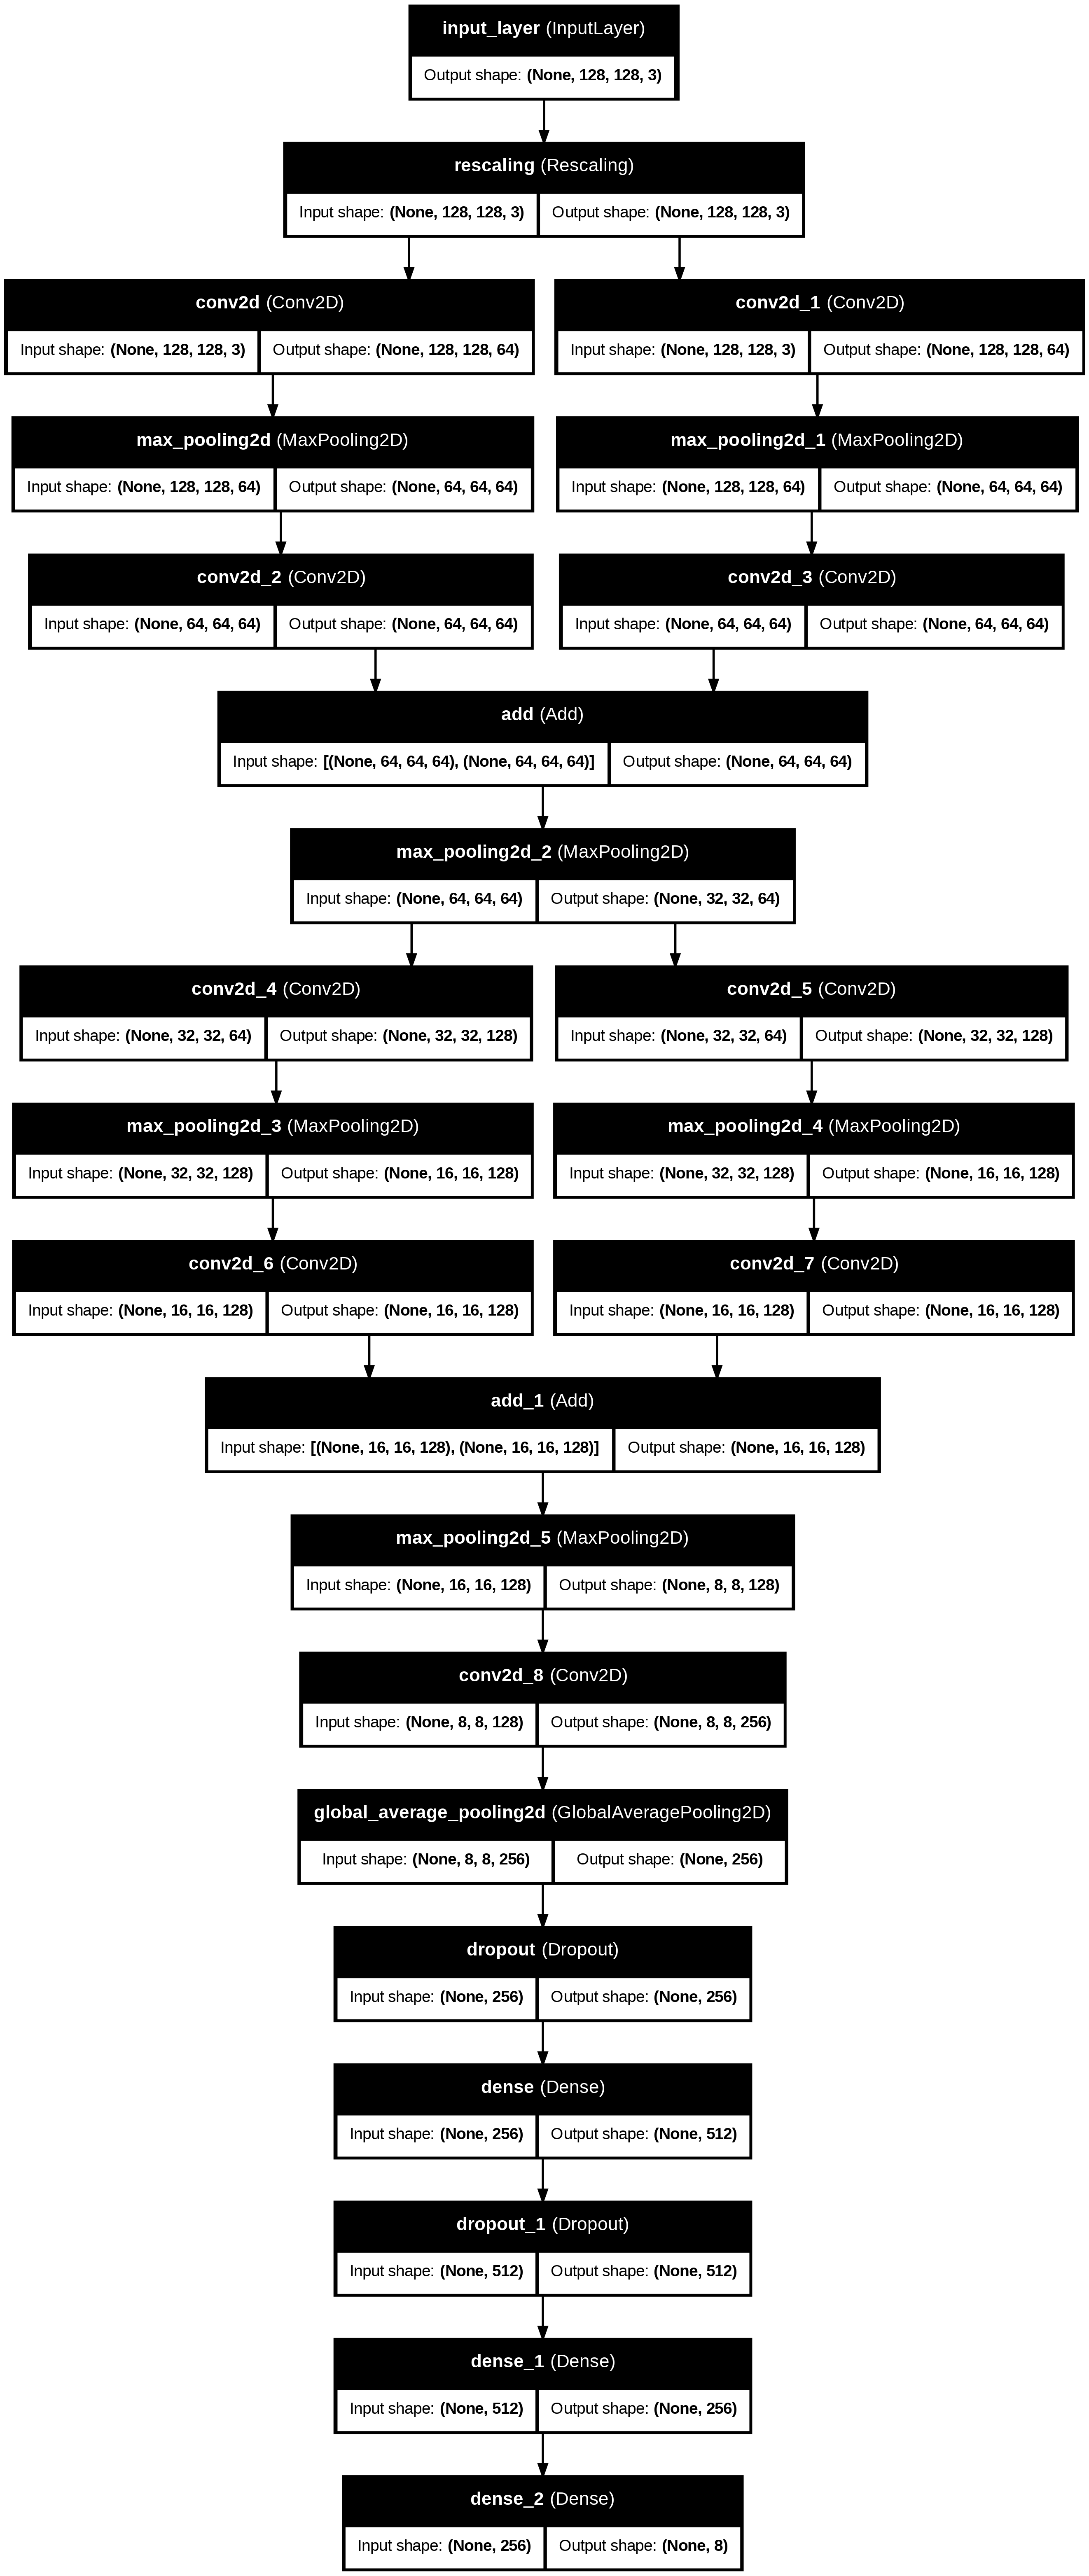

In [13]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='ToolClassification_ResNet.png',
           show_shapes=True, show_layer_names=True,
           dpi=200, rankdir='TB')

In [14]:
model.compile('adam', tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'],)

In [15]:
history = model.fit(train_ds, epochs=100)

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 142ms/step - accuracy: 0.2396 - loss: 1.8436
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.3126 - loss: 1.7174
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.3324 - loss: 1.6470
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.3540 - loss: 1.5919
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.3648 - loss: 1.5881
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.3904 - loss: 1.5370
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.4302 - loss: 1.4663
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.4470 - loss: 1.4056
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.4644 - loss: 1.3748
Epoch 10/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.4849 - loss: 1.3287
Epoch 11/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.5173 - loss: 1.2755
Epoch 12/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/

In [16]:
model.save('ToolClassification.h5')

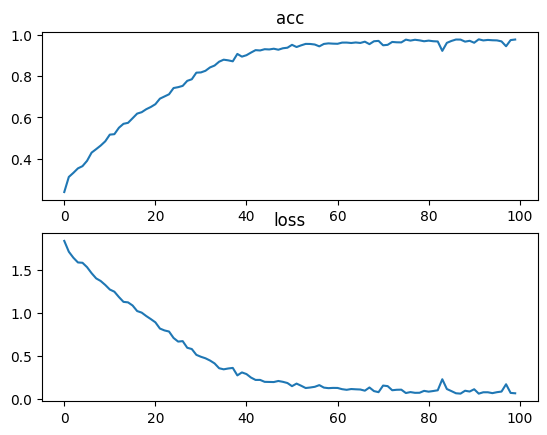

In [17]:
plt.subplot(211)
plt.plot(history.history['accuracy'])
# plt.plot(history.history['val_accuracy'])
plt.title('acc')

plt.subplot(212)
plt.plot(history.history['loss'])
# plt.plot(history.history['val_loss'])
plt.title('loss')

plt.show()

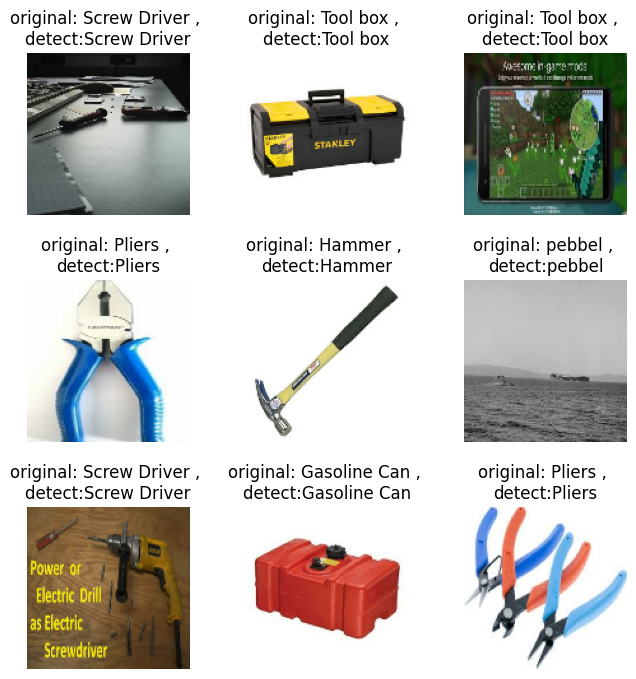

In [18]:
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f'original: {class_names[labels[i]]} , \ndetect:{class_names[tf.argmax(model(images[i:i+1])[0])]}')
        plt.axis("off")

plt.subplots_adjust(hspace=0.4)  # Adds space between rows
plt.show()


/tmp/ipykernel_643/1553580604.py:50: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


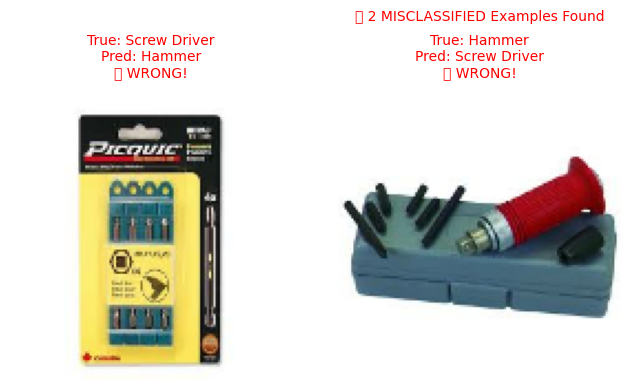

📊 Found 2 misclassified images in first 5 batches


In [25]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Plot ONLY MISCLASSIFIED images (3x3 grid)
plt.figure(figsize=(10,10))

misclassified_count = 0
for images, labels in train_ds.take(6):  # Check more batches
    for i in range(len(images)):
        if misclassified_count >= 9:  # Max 9 images
            break

        # Get true and predicted labels
        true_label = class_names[labels[i].numpy()]
        pred_probs = model(images[i:i+1], training=False)
        pred_label = class_names[tf.argmax(pred_probs[0]).numpy()]

        # ONLY plot if WRONG
        if true_label != pred_label and misclassified_count < 9:
            ax = plt.subplot(3, 3, misclassified_count + 1)

            # Fix image display
            img_array = images[i].numpy()
            if img_array.max() <= 1.0:
                img_display = (img_array * 255).astype("uint8")
            else:
                img_display = img_array.astype("uint8")

            plt.imshow(img_display)
            plt.title(f"True: {true_label}\nPred: {pred_label}\n❌ WRONG!",
                     color='red', fontsize=10, pad=15)
            plt.axis("off")
            misclassified_count += 1

    if misclassified_count >= 9:
        break

# Handle case with no misclassifications
if misclassified_count == 0:
    plt.text(0.5, 0.5, "🎉 PERFECT!\nNo misclassifications found!",
             ha='center', va='center', fontsize=10, color='green')
    plt.axis('off')
    plt.suptitle("Model Classification Results", fontsize=10, color='green')
else:
    plt.suptitle(f"❌ {misclassified_count} MISCLASSIFIED Examples Found",
                fontsize=10, color='red')

plt.subplots_adjust(hspace=0.45, wspace=0.1)
plt.tight_layout()
plt.show()

print(f"📊 Found {misclassified_count} misclassified images in first 5 batches")

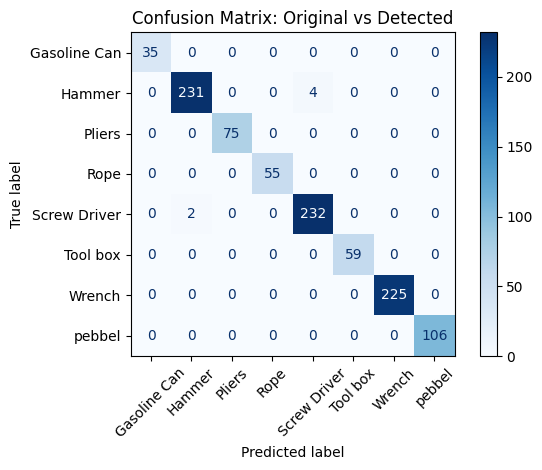

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Collect all true and predicted labels
y_true = []
y_pred = []

for images, labels in train_ds:  # or use test_ds/validation_ds
    true_batch = labels.numpy()
    pred_batch = model.predict(images, verbose=0).argmax(axis=1)

    y_true.extend(true_batch)
    y_pred.extend(pred_batch)

    # Limit for demo (remove this for full dataset)
    if len(y_true) > 1000:
        break

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Create and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Confusion Matrix: Original vs Detected')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import f1_score, classification_report

# Using y_true, y_pred from your confusion matrix code
f1_scores = {}

# 1. MACRO: Unweighted mean (treats all classes equally)
f1_scores['macro'] = f1_score(y_true, y_pred, average='macro')

# 2. MICRO: Global calculation (equivalent to accuracy for multi-class)
f1_scores['micro'] = f1_score(y_true, y_pred, average='micro')

# 3. WEIGHTED: Weighted by class support (best for imbalanced data)
f1_scores['weighted'] = f1_score(y_true, y_pred, average='weighted')

# 4. None: Per-class F1 scores (array)
f1_per_class = f1_score(y_true, y_pred, average=None)

print("=== ALL F1 SCORES ===")
for avg_type, score in f1_scores.items():
    print(f"F1 {avg_type.upper()}: {score:.4f}")

print(f"\nPer-class F1 scores: {f1_per_class.round(4)}")
print(f"Class names: {class_names}")

=== ALL F1 SCORES ===
F1 MACRO: 0.9968
F1 MICRO: 0.9941
F1 WEIGHTED: 0.9941

Per-class F1 scores: [1.     0.9872 1.     1.     0.9872 1.     1.     1.    ]
Class names: ['Gasoline Can', 'Hammer', 'Pliers', 'Rope', 'Screw Driver', 'Tool box', 'Wrench', 'pebbel']


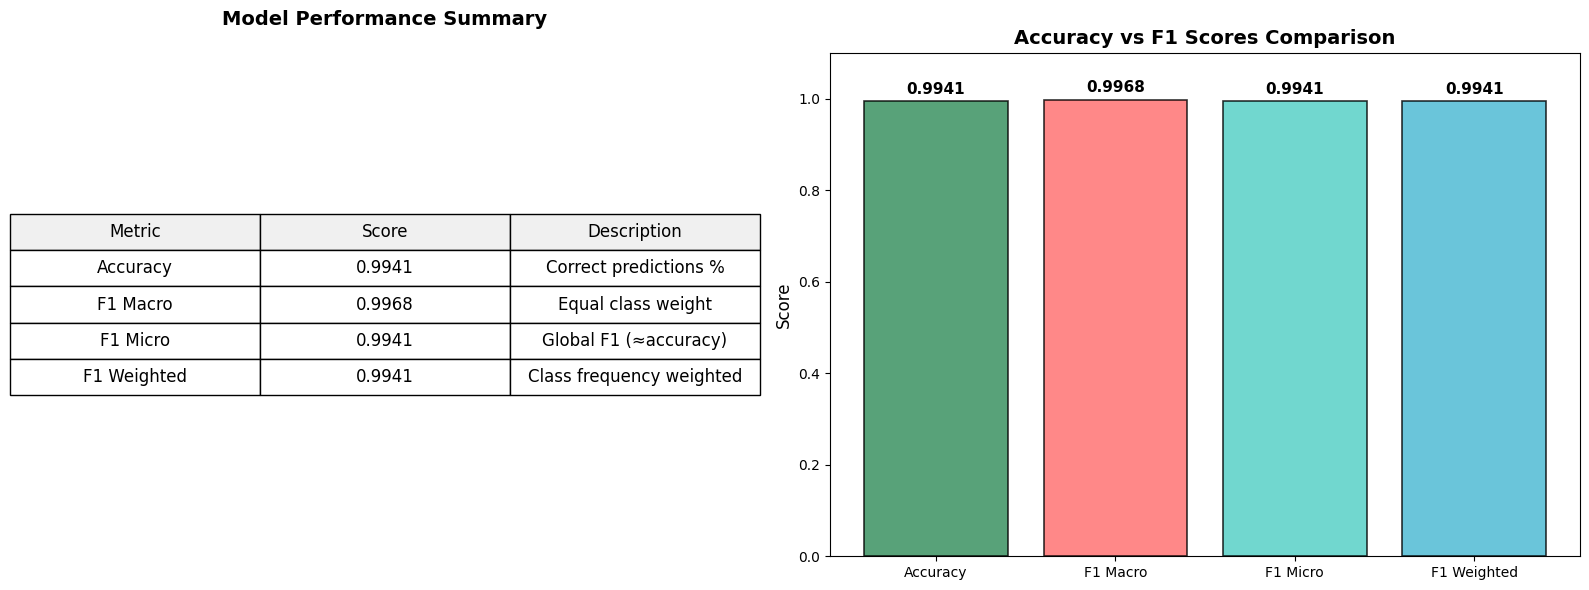

Accuracy: 0.9941
F1 Scores - Macro: 0.9968, Micro: 0.9941, Weighted: 0.9941


In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Calculate metrics (using your y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

# Data for plotting
metrics = ['Accuracy', 'F1 Macro', 'F1 Micro', 'F1 Weighted']
values = [accuracy, f1_macro, f1_micro, f1_weighted]
colors = ['#2E8B57', '#FF6B6B', '#4ECDC4', '#45B7D1']  # Green for accuracy

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. TABLE (left)
table_data = [
    ['Accuracy', f'{accuracy:.4f}', 'Correct predictions %'],
    ['F1 Macro', f'{f1_macro:.4f}', 'Equal class weight'],
    ['F1 Micro', f'{f1_micro:.4f}', 'Global F1 (≈accuracy)'],
    ['F1 Weighted', f'{f1_weighted:.4f}', 'Class frequency weighted']
]
table = ax1.table(cellText=table_data,
                  colLabels=['Metric', 'Score', 'Description'],
                  cellLoc='center', loc='center',
                  colColours=['#F0F0F0']*3)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)
ax1.axis('off')
ax1.set_title('Model Performance Summary', fontsize=14, fontweight='bold', pad=20)

# 2. BAR CHART (right)
bars = ax2.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Accuracy vs F1 Scores Comparison', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1.1)

# Value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.4f}', ha='center', va='bottom',
             fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Console output
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Scores - Macro: {f1_macro:.4f}, Micro: {f1_micro:.4f}, Weighted: {f1_weighted:.4f}")
